In [2]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import community.community_louvain as community_louvain
from networkx.algorithms.community import girvan_newman
from networkx.algorithms.community.quality import modularity

### 🧩 Data Preparation for Graph Construction

This step loads and preprocesses the dataset for community detection analysis.  
We retain only the necessary columns (`person_A`, `person_B`), remove self-loops, and aggregate repeated contacts to form weighted edges.  
The result is an undirected weighted graph `G`, ready for algorithms such as Louvain community detection.

In [3]:

# Load dataset
df = pd.read_csv('datasets/compiled_merged_dataset/final_contact_tracing_data.csv')

# Keep only necessary columns
df = df[['person_A', 'person_B']]

# Remove self-loops
df = df[df['person_A'] != df['person_B']]

# Aggregate repeated contacts as edge weights
edge_df = df.groupby(['person_A', 'person_B']).size().reset_index(name='weight')

# Create an undirected weighted graph
G = nx.Graph()

# Add edges with weights
for _, row in edge_df.iterrows():
    G.add_edge(row['person_A'], row['person_B'], weight=row['weight'])

# Display summary
print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")

# (Optional) Preview a few weighted edges
print(edge_df.head())

Nodes: 794 | Edges: 20018
   person_A  person_B  weight
0         1        55       8
1         1        63       2
2         1       101       1
3         1       106       4
4         1       117      19


### 🧠 Louvain Community Detection

This step applies the **Louvain algorithm** to identify communities within the graph based on edge weights.  
Each node is assigned to a community that maximizes **modularity**, indicating densely connected groups.  
The resulting partition is added as a node attribute and stored in a DataFrame for further analysis or visualization.


In [4]:
# Run Louvain community detection
partition = community_louvain.best_partition(G, weight='weight')

# Add community info to node attributes
nx.set_node_attributes(G, partition, 'community')

# Convert to DataFrame
community_df = pd.DataFrame(list(partition.items()), columns=['Person', 'Community'])
print(community_df.head())
print(f"\nTotal number of detected communities: {community_df['Community'].nunique()}")

   Person  Community
0       1          0
1      55          0
2      63          1
3     101          1
4     106          2

Total number of detected communities: 13


### 🎨 Community Visualization

This section visualizes the detected communities from the Louvain algorithm.  
Each node is colored according to its community assignment, while edges represent connections between individuals.  
The spring layout positions nodes to highlight clusters, making community structures easier to interpret.


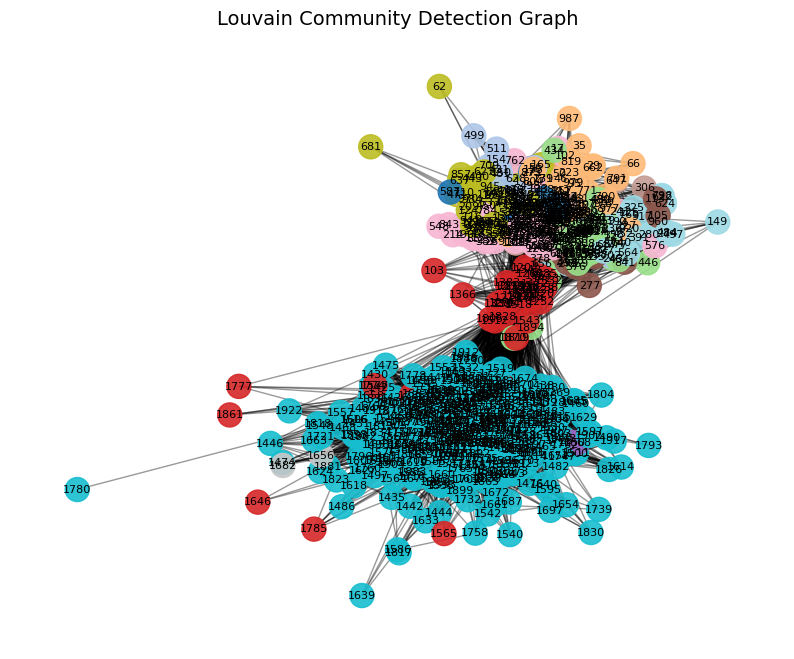

In [5]:
# --- Define Layout for Graph ---
pos = nx.spring_layout(G, seed=42)  # or nx.kamada_kawai_layout(G) for smoother spacing

# --- Draw Graph ---
plt.figure(figsize=(10, 8))

# Draw nodes — color by community
nx.draw_networkx_nodes(
    G, pos,
    node_size=300,
    node_color=list(partition.values()),
    cmap=plt.cm.tab20,
    alpha=0.9
)

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.4)

# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Louvain Community Detection Graph", fontsize=14)
plt.axis("off")
plt.show()

### 📊 Community Size Distribution

This section summarizes and visualizes the number of members in each detected community.  
By counting nodes assigned to each community, we can observe the relative sizes of clusters and identify dominant or smaller groups within the network.  
The bar chart below provides an overview of how evenly or unevenly individuals are distributed across communities.


Community Size Summary:
    Community  count
8           0     28
9           1     28
1           2     63
4           3     50
5           4     44
11          5      3
10          6     17
3           7     52
2           8     59
12          9      2
6          10     39
0          11    376
7          12     33


/var/folders/4d/c9fb2t_j5znf_ftgytncz11h0000gp/T/ipykernel_13955/2986095429.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


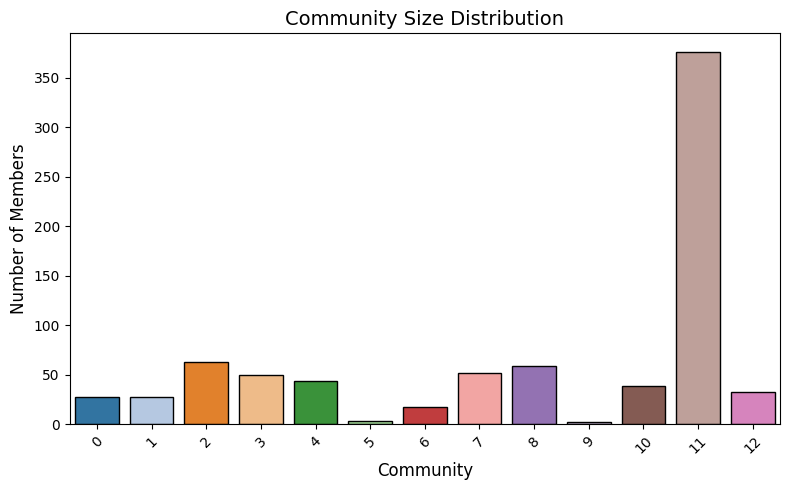

In [6]:
# --- Compute Community Sizes ---
community_sizes = (
    community_df['Community']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'community', 'community': 'size'})
    .sort_values('Community')
)

# --- Display Summary ---
print("Community Size Summary:")
print(community_sizes)

# --- Plot Community Size Distribution ---
plt.figure(figsize=(8, 5))
sns.barplot(
    data=community_sizes,
    x='Community',
    y='count',
    palette='tab20',
    edgecolor='black'
)
plt.title("Community Size Distribution", fontsize=14)
plt.xlabel("Community", fontsize=12)
plt.ylabel("Number of Members", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 📈 Community Detection Metrics

This section evaluates the quality of the detected communities using key **network metrics**:

- **Modularity:** Measures how well the graph is divided into communities, with higher values indicating denser intra-community connections and fewer inter-community links.  
- **Coverage:** Represents the fraction of edges that lie within the detected communities.  
- **Performance:** Evaluates the proportion of correctly classified node pairs — connected within the same community or disconnected across different ones.  

Together, these metrics help assess how effectively the Louvain algorithm has identified meaningful community structures in the network.


In [7]:
import networkx as nx
from community import community_louvain
from networkx.algorithms.community import modularity
from collections import defaultdict
import itertools
import pandas as pd

# --- Run Louvain again if needed ---
partition = community_louvain.best_partition(G, weight='weight')

# --- Convert partition dict to list of sets for metric calculations ---
community_groups = defaultdict(set)
for node, comm in partition.items():
    community_groups[comm].add(node)
communities = list(community_groups.values())

# --- 1️⃣ Modularity ---
mod_score = modularity(G, communities, weight='weight')
print(f"Modularity: {mod_score:.4f}")

# --- 2️⃣ Coverage (manual implementation) ---
# Fraction of edges that fall within communities
intra_edges = sum(
    1 for u, v in G.edges()
    if partition[u] == partition[v]
)
cov_score = intra_edges / G.number_of_edges()
print(f"Coverage: {cov_score:.4f}")

# --- 3️⃣ Performance (manual implementation) ---
# Fraction of correctly classified pairs
def compute_performance(G, partition):
    nodes = list(G.nodes())
    correct = 0
    total = 0
    for u, v in itertools.combinations(nodes, 2):
        same_comm = partition[u] == partition[v]
        connected = G.has_edge(u, v)
        # correct if connected within community OR not connected across communities
        if (same_comm and connected) or (not same_comm and not connected):
            correct += 1
        total += 1
    return correct / total

perf_score = compute_performance(G, partition)
print(f"Performance: {perf_score:.4f}")



Modularity: 0.6573
Coverage: 0.6343
Performance: 0.7548
